In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import warnings

In [41]:
df = pd.read_csv('clean_data_grouped.csv')
df.head()

,job_title,company_name,company_size,location,work_type,work_setting,career_level,education_level,skills_and_tools,posted_at,...,salary_currency,salary_period,city,country,Unnamed: 21,city.1,country.1,job_title_clean,job_seniority,job_title_group
0,QA Engineer,Vertex Technologies,11-50 employees,"Cairo, Egypt",['Full Time'],On-Site,"['Fresh Graduate', 'Junior']",Bachelor's Degree,"['Quality Assurance', 'Test Automation', 'Sele...",4/9/2026 12:56,...,NaN,NaN,Cairo,Egypt,NaN,Cairo,Egypt,trainee automation qa engineer,"['Fresh Graduate', 'Junior']",QA Engineer
1,QA Engineer,Vertex Technologies,11-50 employees,"Cairo, Egypt",['Full Time'],On-Site,"['Junior', 'Senior']",Bachelor's Degree,"['Automation Testing', 'Agile Methodologies', ...",4/9/2026 12:57,...,NaN,NaN,Cairo,Egypt,NaN,Cairo,Egypt,junior automation qa engineer,"['Junior', 'Senior']",QA Engineer
2,QA Engineer,Vertex Technologies,11-50 employees,"Cairo, Egypt",['Full Time'],On-Site,"['Junior', 'Senior']",Bachelor's Degree,"['Test Automation', 'Selenium', 'Cypress', 'CI...",4/9/2026 12:57,...,NaN,NaN,Cairo,Egypt,NaN,Cairo,Egypt,middle automation qa engineer,"['Junior', 'Senior']",QA Engineer
3,Technical Support Engineer,EAST,101-500 employees,"Cairo, Egypt",['Full Time'],On-Site,"['Junior', 'Mid-Level']",Not Specified,"['Dynamics AX 2012', 'Microsoft Office 365', '...",4/9/2026 13:41,...,NaN,NaN,Cairo,Egypt,NaN,Cairo,Egypt,application support engineer,"['Junior', 'Mid-Level']",Technical Support Engineer
4,Management,IntComp Tech Intelligence,11-50 employees,"Cairo, Egypt",['Full Time'],On-Site,"['Mid-Level', 'Lead / Principal']",Not Specified,"['Agile', 'Azure', 'Management', 'Software Dev...",4/9/2026 14:47,...,NaN,NaN,Cairo,Egypt,NaN,Cairo,Egypt,team lead,"['Mid-Level', 'Lead / Principal']",Management


In [42]:
df_analysis = df[['job_title']]

In [43]:
df_analysis['min_experience_years'] = df['min_experience_years']
df_analysis['max_experience_years'] = df['max_experience_years']
df_analysis['Avg_experience_years'] = (df['min_experience_years'] + df['max_experience_years']) / 2

C:\Users\DELL\AppData\Local\Temp\ipykernel_26256\1337534624.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_analysis['min_experience_years'] = df['min_experience_years']
C:\Users\DELL\AppData\Local\Temp\ipykernel_26256\1337534624.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_analysis['max_experience_years'] = df['max_experience_years']
C:\Users\DELL\AppData\Local\Temp\ipykernel_26256\1337534624.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.


In [9]:
df["career_levels_array"].head()

0    [Junior Level / Fresh Grad]
1    [Junior Level / Fresh Grad]
2                  [Non-Manager]
3    [Junior Level / Fresh Grad]
4                  [Non-Manager]
Name: career_levels_array, dtype: object

In [44]:
df_analysis["career_levels"] = df["career_level"]

C:\Users\DELL\AppData\Local\Temp\ipykernel_26256\1992364567.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_analysis["career_levels"] = df["career_level"]


In [45]:
df_analysis.to_csv("output.csv", index=False)

In [15]:
df_analysis.to_csv("output.csv", index=False)

In [20]:
df_analysis['city'] = df['city']

C:\Users\DELL\AppData\Local\Temp\ipykernel_26256\1295244210.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_analysis['city'] = df['city']


In [21]:
df_analysis.to_csv("output.csv", index=False)

In [ ]:
import ast
def process_jobs_data(file_path="output.csv"):
    df = pd.read_csv(file_path)

    def parse_levels(val):
        if isinstance(val, str):
            try:
                parsed = ast.literal_eval(val)
                if isinstance(parsed, list):
                    return parsed
            except (ValueError, SyntaxError):
                pass
        if isinstance(val, list):
            return val
        return []

    df['career_levels'] = df['career_levels'].apply(parse_levels)

    target_levels = [
        'Fresh Graduate',
        'Junior',
        'Mid-Level',
        'Senior',
        'Lead / Principal',
        'Executive / Expert'
    ]

    for level in target_levels:
        df[level] = df['career_levels'].apply(lambda x: 1 if level in x else 0)

    df['exp_range'] = list(zip(df['min_experience_years'], df['max_experience_years']))

    agg_dict = {
        'job_count': ('job_title', 'size'),
        'experience_ranges': ('exp_range', lambda x: list(set(x)))
    }
    for level in target_levels:
        agg_dict[level] = (level, 'sum')

    final_df = df.groupby('job_title', as_index=False).agg(**agg_dict)

    final_df[target_levels] = final_df[target_levels].fillna(0).astype(int)

    columns_order = ['job_title', 'job_count', 'experience_ranges'] + target_levels
    final_df = final_df[columns_order]

    return final_df

final_dataframe = process_jobs_data("output.csv")
    


In [73]:
final_dataframe.to_csv("grouped_output.csv", index=False)

In [80]:
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.max_open_warning': 0})

levels = [
    'Fresh Graduate', 'Junior', 'Mid-Level', 'Senior', 
    'Lead / Principal', 'Executive / Expert'
]

def load_dataset(file_path="grouped_output.csv"):
    df = pd.read_csv(file_path)
    
    def parse_exp(val):
        if pd.isna(val) or val == "":
            return []
        if isinstance(val, str):
            try:
                res = ast.literal_eval(val)
                return res if isinstance(res, list) else []
            except (ValueError, SyntaxError):
                return []
        return val if isinstance(val, list) else []
        
    df['experience_ranges'] = df['experience_ranges'].apply(parse_exp)
    return df

df = load_dataset()


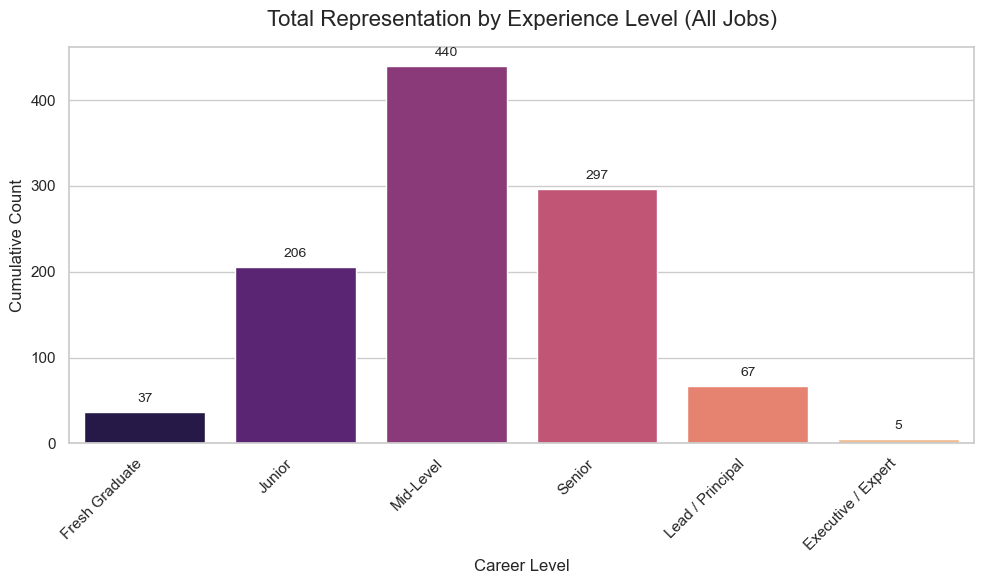

In [81]:
def plot_global_experience_distribution(df, levels):
    plt.figure(figsize=(10, 6))
    level_counts = df[levels].sum()
    
    ax = sns.barplot(x=levels, y=level_counts[levels].values, palette='magma')
    plt.title('Total Representation by Experience Level (All Jobs)', fontsize=16, pad=15)
    plt.xlabel('Career Level', fontsize=12)
    plt.ylabel('Cumulative Count', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(f"{int(height)}", 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='bottom', fontsize=10, xytext=(0, 5), 
                    textcoords='offset points')
                    
    plt.tight_layout()
    plt.show()

plot_global_experience_distribution(df, levels)


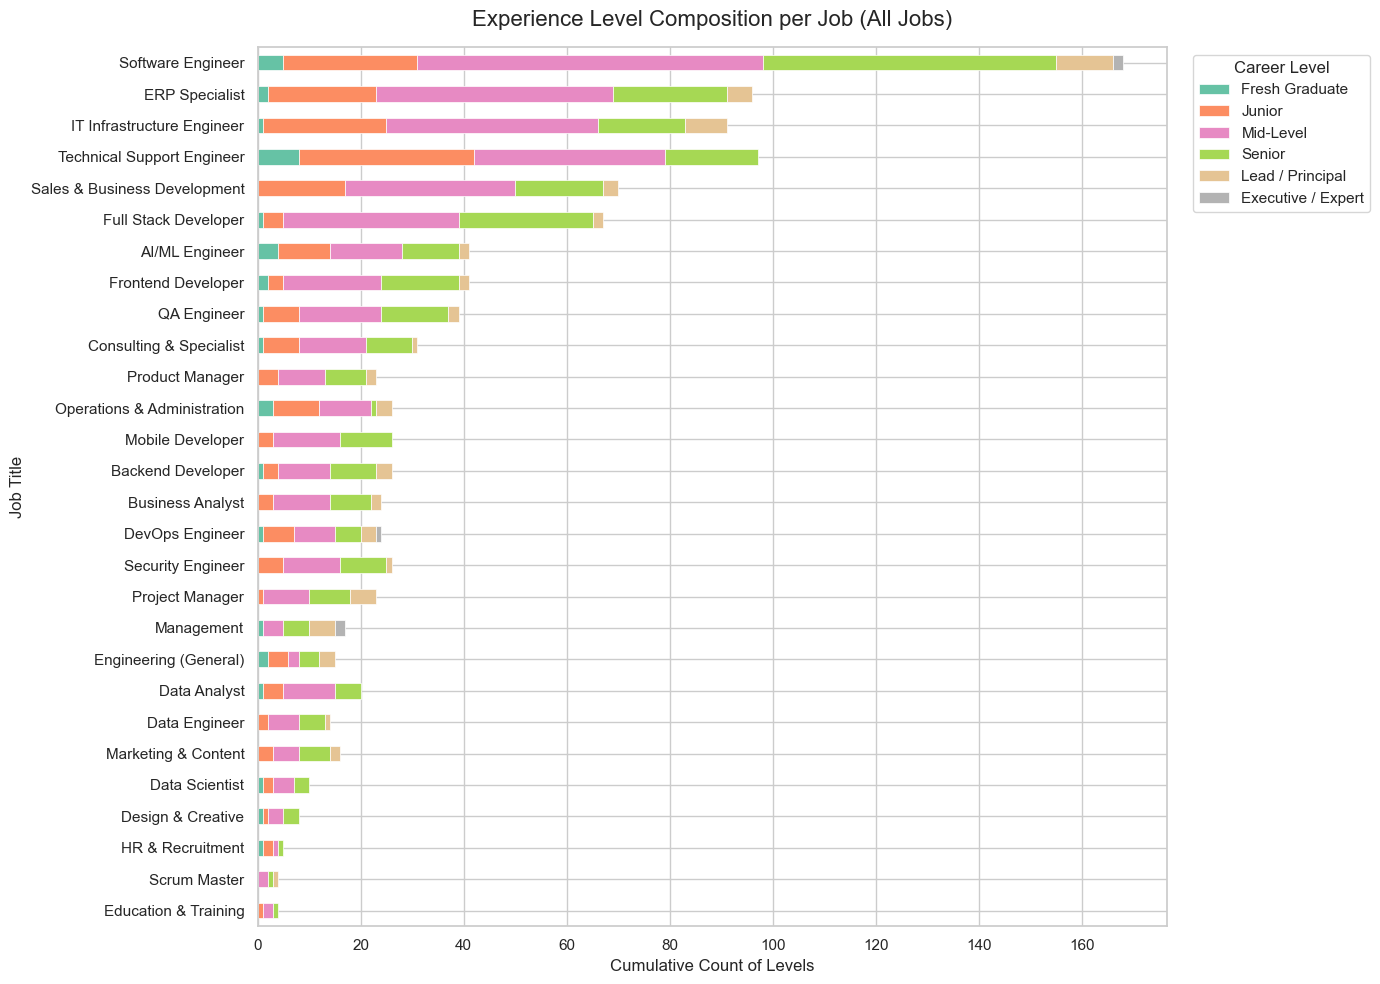

In [82]:
def plot_stacked_levels_all_jobs(df, levels):
    df_sorted = df.sort_values('job_count', ascending=True).set_index('job_title')[levels]
    
    # Scale figure height dynamically 
    fig_height = max(10, len(df_sorted) * 0.35)
    
    ax = df_sorted.plot(kind='barh', stacked=True, figsize=(14, fig_height), 
                        colormap='Set2', edgecolor='white', linewidth=0.5)
    plt.title('Experience Level Composition per Job (All Jobs)', fontsize=16, pad=15)
    plt.xlabel('Cumulative Count of Levels', fontsize=12)
    plt.ylabel('Job Title', fontsize=12)
    
    plt.legend(title='Career Level', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

plot_stacked_levels_all_jobs(df, levels)


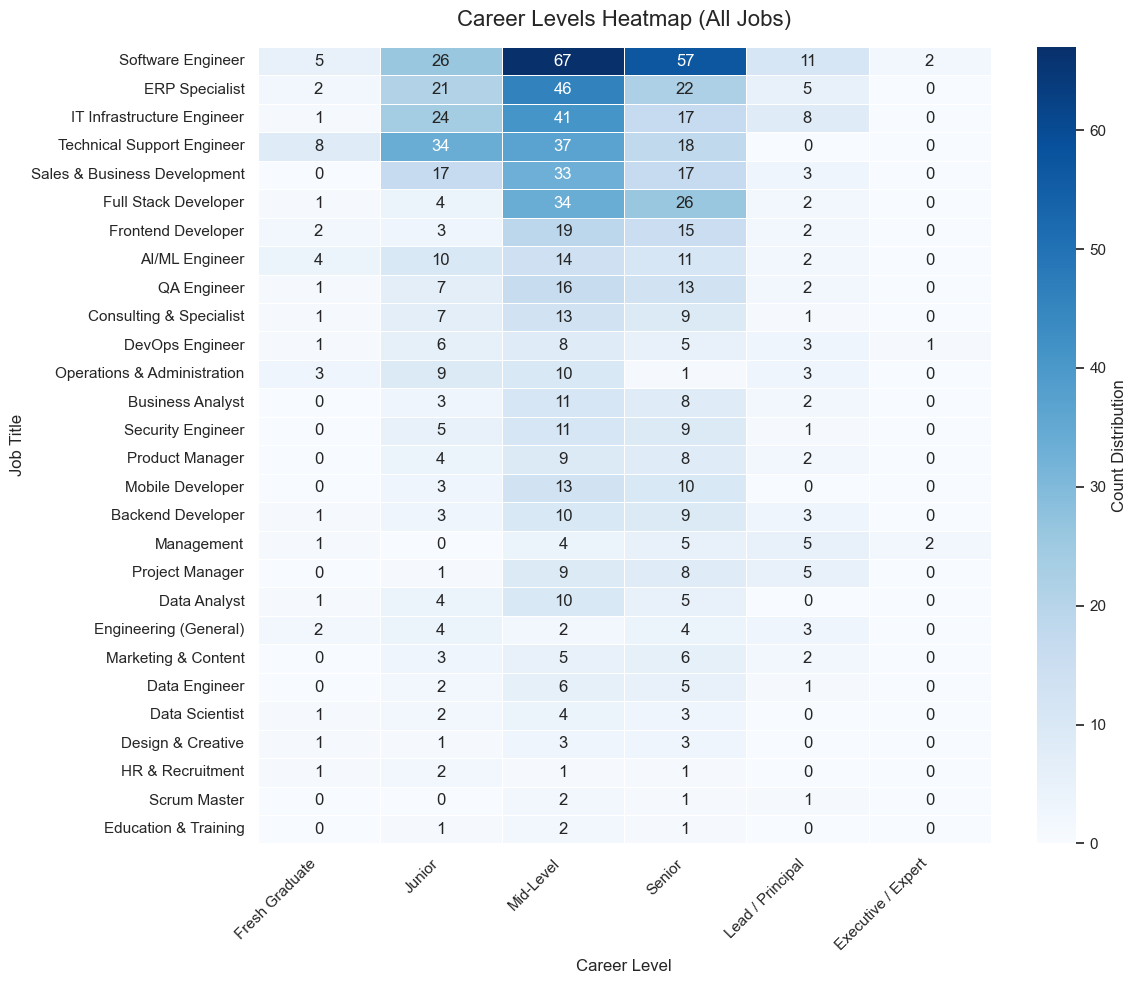

In [83]:
def plot_heatmap_all_jobs(df, levels):
    df_sorted = df.sort_values('job_count', ascending=False).set_index('job_title')[levels]
    
    fig_height = max(10, len(df_sorted) * 0.35)
    
    plt.figure(figsize=(12, fig_height))
    sns.heatmap(df_sorted, annot=True, fmt='g', cmap='Blues', linewidths=.5, cbar_kws={'label': 'Count Distribution'})
    plt.title('Career Levels Heatmap (All Jobs)', fontsize=16, pad=15)
    plt.xlabel('Career Level', fontsize=12)
    plt.ylabel('Job Title', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    
    plt.tight_layout()
    plt.show()

plot_heatmap_all_jobs(df, levels)


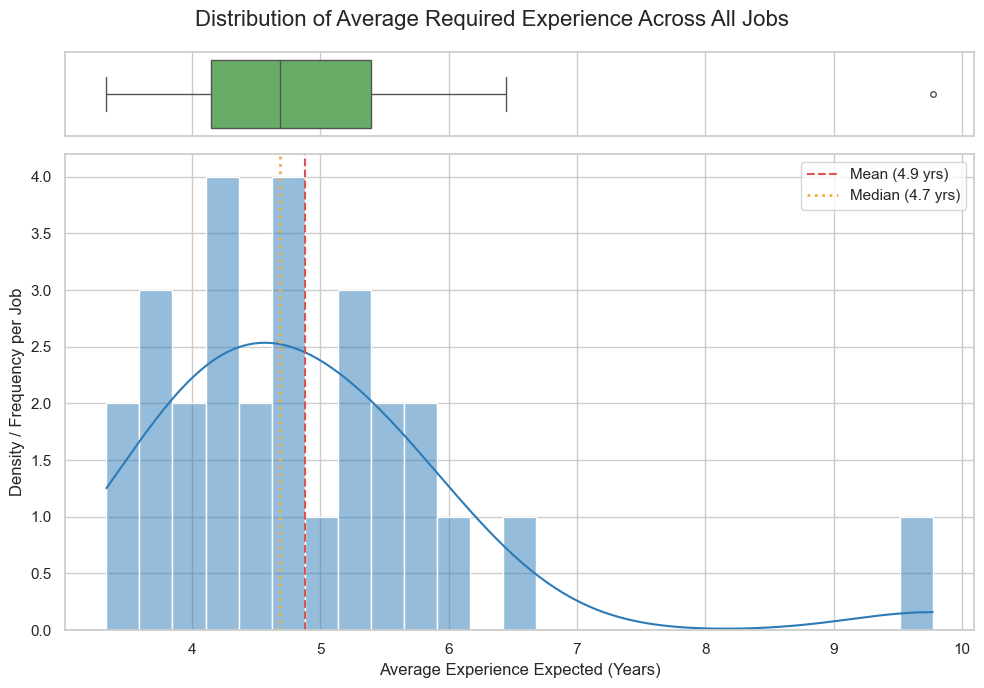

In [84]:
def plot_experience_range_distribution(df):
    def calc_mean_exp(ranges):
        if not ranges:
            return np.nan
        avgs = [(r[0] + r[1]) / 2 for r in ranges]
        return np.mean(avgs)
        
    df_plot = df.copy()
    df_plot['avg_experience_years'] = df_plot['experience_ranges'].apply(calc_mean_exp)
    plot_data = df_plot['avg_experience_years'].dropna()
    
    fig, (ax_box, ax_hist) = plt.subplots(2, sharex=True, gridspec_kw={"height_ratios": (.15, .85)}, figsize=(10, 7))
    
    sns.boxplot(x=plot_data, ax=ax_box, color="#5CB85C", fliersize=4)
    sns.histplot(plot_data, ax=ax_hist, bins=min(25, len(plot_data)), kde=True, color='#2C7BB6', edgecolor='white')
    
    plot_mean = plot_data.mean()
    plot_median = plot_data.median()
    
    ax_hist.axvline(plot_mean, color='#D9534F', linestyle='dashed', linewidth=1.5, label=f'Mean ({plot_mean:.1f} yrs)')
    ax_hist.axvline(plot_median, color='#F0AD4E', linestyle='dotted', linewidth=2, label=f'Median ({plot_median:.1f} yrs)')
    
    ax_box.set(xlabel='', yticks=[])
    ax_hist.set_xlabel('Average Experience Expected (Years)', fontsize=12)
    ax_hist.set_ylabel('Density / Frequency per Job', fontsize=12)
    ax_hist.legend()
    
    plt.suptitle('Distribution of Average Required Experience Across All Jobs', fontsize=16)
    plt.tight_layout()
    plt.show()

plot_experience_range_distribution(df)
